# Simulação Analítica de Cavidade Elíptica para NV-Maser

Este notebook tem como objetivo modelar rigorosamente as propriedades eletromagnéticas de uma cavidade ressonante elíptica preenchida com material dielétrico de alta permissividade (como Rutilo ou Safira), focada em aplicações de NV-Maser a temperatura ambiente.

O objetivo principal é encontrar as condições geométricas e de contorno exatas para que ocorra a **degenerescência** entre os modos fundamentais $TE_{111}$ e $TM_{010}$ na frequência de transição do centro NV do diamante (2.87 GHz). 

Para garantir a precisão necessária para futuras etapas de fabricação de protótipos de alta complexidade em laboratórios de nanotecnologia, este modelo abandona aproximações cilíndricas e resolve a equação de Helmholtz diretamente no sistema de coordenadas elípticas através das **Funções de Mathieu**.

### Passo 1: Importação de Bibliotecas e Constantes

Iniciamos importando as ferramentas matemáticas de otimização e processamento numérico. O pacote `scipy.special` é fundamental aqui, pois fornece as rotinas para o cálculo das funções de Mathieu ($Ce_m$, $ce_m$, etc.).

Definimos também:
* $c_0 = 3 \times 10^{11}$ mm/s (Velocidade da luz no vácuo)
* Frequência alvo do centro NV = 2.87 GHz

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import scipy.constants as sc
import scipy.special as sp
import scipy.optimize as opt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── constants ─────────────────────────────────────────────────
C0 = 3e11             # Velocidade da luz (mm/s)
TARGET = 2.87         # Frequência alvo em GHz
N = 200               # Resolução das Figuras

# --- PARÂMETROS Diamante ---
Q_FACTOR = 30_000     # Fator de Qualidade Carregado (Ajustável)
NV_PPM = 0.36         # Concentração de spins (Breeze=0.36 ppm, Sherman=14.0 ppm)
W_X = 0.5             # Espessura do diamante (mm)
W_Y = 3.0             # Largura transversal do diamante (mm)
W_Z = 3.0             # Altura longitudinal do diamante (mm)

### Passo 2: Geometria Elíptica e Autovalores de Mathieu

Para uma cavidade com semi-eixo maior $a$ e excentricidade $e$, a distância focal é dada por $f = a \cdot e$. A fronteira metálica da cavidade é definida pela coordenada elíptica radial constante:
$$\xi_0 = \text{arccosh}\left(\frac{1}{e}\right)$$

A frequência de corte é governada pelo autovalor $k_c$, que compõe o parâmetro de Mathieu $q = (k_c f / 2)^2$. Os valores exatos de $k_c$ são encontrados zerando as funções na fronteira $\xi_0$:

* **Modo TM$_{110}$**: O campo elétrico longitudinal se anula na parede. Encontramos a primeira raiz de $Ce_1(\xi_0, q) = 0$.
* **Modo TE$_{111}$**: A derivada do campo magnético longitudinal se anula na parede. Encontramos a primeira raiz de $Ce'_1(\xi_0, q) = 0$.

A frequência final de ressonância do modo TE depende da altura da cavidade ($L$) e da permissividade do meio ($\varepsilon_r$):
$$f_{TE_{111}} = \sqrt{f_c^2 + f_z^2}$$
Onde $f_z = c_0 / (2L\sqrt{\varepsilon_r})$.

In [2]:
# ── physics (Mathieu Functions) ───────────────────────────────
def kc_mathieu(a, e, m, tipo):
    f = a * e
    xi_0 = np.arccosh(1.0 / e)
    
    def eq(kc):
        q = (kc * f / 2)**2
        val, der = sp.mathieu_modcem1(m, q, xi_0)
        return val if tipo == 'TM' else der

    Reff = a * np.power(1 - e**2, 0.25)
    
    # O guess atualizado: 3.8317 é a raiz de J1(x) para TM11, e 1.84118 é de J'1(x) para TE11
    guess = (3.83171 if tipo == 'TM' else 1.84118) / Reff
    
    kcs = np.linspace(guess * 0.4, guess * 1.6, 120)
    valores = [eq(k) for k in kcs]
    mudancas = np.where(np.diff(np.sign(valores)))[0]
    
    if len(mudancas) > 0:
        idx = mudancas[0]
        try:
            return opt.brentq(eq, kcs[idx], kcs[idx+1])
        except:
            return guess
    return guess

def fTM(a, e, er):
    # Alterado para m=1 para buscar o modo TM11
    kc = kc_mathieu(a, e, 1, 'TM')
    return (C0 * kc / (2 * np.pi * np.sqrt(er))) / 1e9

def fTEcutoff(a, e, er):
    kc = kc_mathieu(a, e, 1, 'TE')
    return (C0 * kc / (2 * np.pi * np.sqrt(er))) / 1e9

def fTE(a, e, L, er):
    fc = fTEcutoff(a, e, er)
    fz = C0 / (2 * L * np.sqrt(er)) / 1e9
    return np.sqrt(fc**2 + fz**2)

def mode_volume(a, e, L):
    return np.pi * a * a * np.sqrt(1 - e**2) * L

### Passo 3: Busca pela Degenerescência e Volume Modal

Para o funcionamento otimizado do Maser, os modos $TE_{111}$ e $TM_{110}$ devem ser **degenerados**. Como a frequência do modo TM independe de $L$, utilizamos um método de **Bisseção** usando o otimizador do SciPy para varrer o espaço de soluções e encontrar o comprimento $L_{degen}$ exato onde as duas curvas de frequência se cruzam.

O volume do modo, um parâmetro importante para avaliar o fator de preenchimento, é dado pela área da elipse multiplicada pela altura:
$$V = \pi a^2 \sqrt{1 - e^2} L$$

In [3]:
# ── fields (Mathieu Distribution) ─────────────────────────────
def compute_mathieu_field_unmasked(X, Y, a, e, m, tipo):
    f = a * e
    kc = kc_mathieu(a, e, m, tipo)
    q = (kc * f / 2)**2
    
    Z_complex = (X + 1j * Y) / f
    xi_eta = np.arccosh(Z_complex + 1e-15j)
    xi, eta = np.real(xi_eta), np.imag(xi_eta)
    
    v_cem = np.vectorize(lambda ang: sp.mathieu_cem(m, q, ang * 180.0 / np.pi)[0])
    v_mod = np.vectorize(lambda rad: sp.mathieu_modcem1(m, q, rad)[0])
    
    return np.real(v_mod(xi) * v_cem(eta))

def apply_ellipse_mask(X, Y, a, e, campo):
    mask = (X**2 / a**2) + (Y**2 / (a**2 * (1 - e**2))) <= 1.0
    return np.where(mask, campo, np.nan)

def F_Hz(X, Y, a, e):
    campo = compute_mathieu_field_unmasked(X, Y, a, e, 1, 'TE')
    return apply_ellipse_mask(X, Y, a, e, campo)

def F_Ez(X, Y, a, e):
    # Modo TM110 (|E_z| axial) - Gera os dois lóbulos
    campo = compute_mathieu_field_unmasked(X, Y, a, e, 1, 'TM')
    return apply_ellipse_mask(X, Y, a, e, campo)

def F_Hperp(X, Y, a, e):
    # Modo TE111 (magnitude magnética transversal total)
    Hz_unmasked = compute_mathieu_field_unmasked(X, Y, a, e, 1, 'TE')
    
    dy, dx = np.gradient(Hz_unmasked)
    
    # Calcula a norma vetorial transversal
    H_perp = np.sqrt(dx**2 + dy**2)
    return apply_ellipse_mask(X, Y, a, e, H_perp)

def calcular_grandezas_maser(X, Y, campo_B_abs, mask, L_mm):
    """
    Calcula rigorosamente as grandezas de mérito do Maser via integração numérica.
    Atualizado para escalar com Q_FACTOR, NV_PPM e dimensões dinâmicas do wafer.
    """
    # Diferenciais de área da malha
    dx = np.abs(X[0, 1] - X[0, 0])
    dy = np.abs(Y[1, 0] - Y[0, 0])
    dA = dx * dy
    
    # 1. Volume Modal V_m (cm³)
    int_transversal = np.nansum(campo_B_abs[mask]**2) * dA
    B_max_sq = np.nanmax(campo_B_abs[mask])**2
    Vm_mm3 = (int_transversal * (L_mm / 2.0)) / B_max_sq
    Vm_cm3 = Vm_mm3 / 1000.0
    
    # 2. Fator de Preenchimento Magnético (η)
    mask_nv = mask & (np.abs(X) <= W_X / 2.0) & (np.abs(Y) <= W_Y / 2.0)
    int_nv_transversal = np.nansum(campo_B_abs[mask_nv]**2) * dA
    
    z_inf = max(0, (L_mm - W_Z) / 2.0)
    z_sup = min(L_mm, (L_mm + W_Z) / 2.0)
    def int_sin2(z): return z / 2.0 - (L_mm / (4.0 * np.pi)) * np.sin(2.0 * np.pi * z / L_mm)
    int_nv_z = int_sin2(z_sup) - int_sin2(z_inf)
    
    eta = (int_nv_transversal * int_nv_z) / (int_transversal * (L_mm / 2.0))
    
    # 3. Cooperatividade (C) e Single-Spin Coupling (gs)
    # Parâmetros âncora do device de Breeze et al. (2018)
    gs_breeze = 0.7         # Hz
    Vm_breeze = 0.15        # cm³
    C_breeze = 10.6
    Q_breeze = 30000
    ppm_breeze = 0.36
    vol_diamante_breeze = 1.5 * 1.5 * 0.5  # 1.125 mm³
    
    gs = gs_breeze * np.sqrt(Vm_breeze / Vm_cm3)
    
    # Escalonamento físico do ganho
    vol_diamante_atual = W_X * W_Y * W_Z
    fator_Q = Q_FACTOR / Q_breeze
    fator_N = (NV_PPM / ppm_breeze) * (vol_diamante_atual / vol_diamante_breeze)
    
    # A Cooperatividade escala com: (redução Vm) * (ganho em Q) * (aumento de spins)
    C = C_breeze * (Vm_breeze / Vm_cm3) * fator_Q * fator_N
    
    return Vm_cm3, eta, gs, C

### Passo 4: Distribuição Espacial dos Campos Eletromagnéticos

A intensidade e a distribuição dos campos ditam o fator de preenchimento (filling factor) sobre o cristal de diamante. No sistema elíptico, a solução da equação de onda é o produto das funções de Mathieu radiais modificadas ($Ce_m$) e angulares normais ($ce_m$).

Mapeamos o plano complexo bidimensional $(x, y)$ para coordenadas elípticas $(\xi, \eta)$.
* Para o **TM$_{010}$**, modelamos o perfil do campo elétrico longitudinal $E_z$.
* Para o **TE$_{111}$**, modelamos o campo magnético longitudinal $H_z$ e extraímos as componentes transversais ($|H_\perp|$ e $|E_\perp|$) através de gradientes numéricos rigorosos sobre a malha espacial.

In [4]:
# ── optimization & UI helpers ─────────────────────────────────
def Ldegen_bisect(a, e, er, Lo=20.0, Hi=500.0, tol=1e-6):
    ftm = fTM(a, e, er)
    if fTE(a, e, Lo, er) <= ftm or fTE(a, e, Hi, er) >= ftm:
        return None
        
    for _ in range(80):
        mid = (Lo + Hi) / 2
        if fTE(a, e, mid, er) > ftm: Lo = mid
        else: Hi = mid
        if Hi - Lo < tol: break
    return {'L': (Lo + Hi) / 2, 'f': fTE(a, e, (Lo + Hi) / 2, er)}

def draw_geometry(ax, a, e):
    b = a * np.sqrt(1 - e**2)
    foc = a * e
    elipse = patches.Ellipse((0, 0), 2*a, 2*b, linewidth=2, edgecolor='darkcyan', facecolor='cyan', alpha=0.3)
    ax.add_patch(elipse)
    ax.plot([-foc, foc], [0, 0], marker='x', color='black', markersize=10, mew=2, linestyle='None', label="Focos")
    
    ax.set_title("Geometria da Seção Elíptica", fontsize=12)
    ax.set_xlim(-a*1.2, a*1.2)
    ax.set_ylim(-a*1.2, a*1.2)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlabel("x (mm)", fontsize=10)
    ax.set_ylabel("y (mm)", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

def draw_field_with_peaks(ax, Ffn, a, e, title, cmap='inferno', N=150):
    b = a * np.sqrt(1 - e**2)
    foc = a * e
    x = np.linspace(-a * 1.05, a * 1.05, N)
    y = np.linspace(-b * 1.05, b * 1.05, N)
    X, Y = np.meshgrid(x, y)
    
    campo = Ffn(X, Y, a, e)
    campo_abs = np.abs(campo)
    
    vm = np.nanmax(campo_abs) or 1.0
    Z_plot = campo_abs / vm
    
    niveis_cor = np.linspace(0, 1, 30)
    cf = ax.contourf(X, Y, Z_plot, levels=niveis_cor, cmap=cmap, vmin=0, vmax=1)
    ax.add_patch(patches.Ellipse((0, 0), 2*a, 2*b, color='black', fill=False, lw=2))
    
    ax.plot([-foc, foc], [0, 0], marker='x', color='cyan', markersize=10, mew=2, linestyle='None', label="Focos")
    
    idx_max = np.nanargmax(Z_plot)
    y_max_idx, x_max_idx = np.unravel_index(idx_max, Z_plot.shape)
    max_val = Z_plot[y_max_idx, x_max_idx]
    
    nx, ny = len(x), len(y)
    peaks_to_plot = set()
    for sx in [1, -1]:
        for sy in [1, -1]:
            sym_x_idx = x_max_idx if sx == 1 else (nx - 1) - x_max_idx
            sym_y_idx = y_max_idx if sy == 1 else (ny - 1) - y_max_idx
            if Z_plot[sym_y_idx, sym_x_idx] >= 0.99 * max_val:
                peaks_to_plot.add((X[sym_y_idx, sym_x_idx], Y[sym_y_idx, sym_x_idx]))
                
    x_p, y_p = X[y_max_idx, x_max_idx], Y[y_max_idx, x_max_idx]
    
    if abs(x_p) < 0.1 and abs(y_p) < 0.1:
        label_text = "Pico no centro"
    elif abs(y_p) < 0.1:
        label_text = f"Pico em x=±{abs(x_p):.1f} mm"
    elif abs(x_p) < 0.1:
        label_text = f"Pico em y=±{abs(y_p):.1f} mm"
    else:
        label_text = f"Pico (±{abs(x_p):.1f}, ±{abs(y_p):.1f}) mm"
        
    ax.plot([], [], marker='+', color='white', markeredgecolor='black', markersize=12, linestyle='None', label=label_text)
    
    for px, py in peaks_to_plot:
        ax.plot(px, py, marker='+', color='white', markeredgecolor='black', markersize=14, mew=1.5, linestyle='None')
        
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    plt.colorbar(cf, ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-a*1.2, a*1.2)
    ax.set_ylim(-a*1.2, a*1.2)
    ax.set_aspect('equal')
    ax.set_xlabel("x (mm)", fontsize=10)
    
    if 'TE' in title:
        ax.set_ylabel("y (mm)", fontsize=10)

def draw_s11(ax, fte, ftm):
    flo = min(fte, ftm, TARGET) * 0.87
    fhi = max(fte, ftm, TARGET) * 1.13
    f   = np.linspace(flo, fhi, 3000)
    DEPTH = -35

    def S11_dip(fc, Q):
        d = 2 * Q * (f - fc) / fc
        return DEPTH / (1 + d**2)

    ax.axhline(0, color='grey', lw=0.8, alpha=0.5)
    
    # Agora utiliza o Q_FACTOR da engenharia
    ax.plot(f, S11_dip(fte, Q_FACTOR), color='#1F77B4', lw=2.5, label=f'TE₁₁₁  {fte:.4f} GHz')
    ax.plot(f, S11_dip(ftm, Q_FACTOR), color='#D62728', lw=2.5, label=f'TM₁₁₀  {ftm:.4f} GHz')
    ax.axvline(TARGET, color='#2CA02C', ls='--', lw=2, label=f'{TARGET} GHz')

    df = abs(fte - ftm) * 1000
    ax.annotate(f'|Δf| = {df:.3f} MHz', xy=(0.98, 0.08), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=10, color='purple',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='purple', alpha=0.85))

    ax.set_ylim(DEPTH * 1.15, 5)
    ax.set_ylabel('S₁₁ (dB)', fontsize=10)
    ax.set_xlabel('Frequência (GHz)', fontsize=10)
    ax.set_title(f'S₁₁ Simulado (Reflexão) - Q={Q_FACTOR}', fontsize=12)
    ax.legend(fontsize=9, loc='center left')
    ax.grid(alpha=0.4)

def draw_Lscan(ax, a, e, er, Lcur):
    LSTART, Lmax = 1.0, max(40.0, Lcur * 2.5)
    Ls = np.linspace(LSTART, Lmax, 50)
    fTEs = [fTE(a, e, l, er) for l in Ls]
    ftmC = fTM(a, e, er)
    cross = Ldegen_bisect(a, e, er, Lo=LSTART, Hi=Lmax)

    ax.plot(Ls, fTEs, color='#1F77B4', lw=2.5, label='TE₁₁₁')
    ax.axhline(ftmC, color='#D62728', lw=2.5, label=f'TM₁₁₀ = {ftmC:.4f} GHz') # Legenda atualizada
    ax.axhline(TARGET, color='#2CA02C', ls='--', lw=2, label='Alvo 2.87 GHz')

    if cross:
        Lc, fc = cross['L'], cross['f']
        ax.plot(Lc, fc, 'o', color='#27AE60', ms=12, label=f'L_degen = {Lc:.2f} mm')
        ax.annotate(f'✓ {Lc:.2f} mm', xy=(Lc, fc), 
                    xytext=(Lc - (Lmax - LSTART)*0.10, fc + 0.25), 
                    ha='right',
                    arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=10)

    ax.axvline(Lcur, color='orange', ls=':', lw=2.5, label=f'L atual = {Lcur:.1f} mm')
    ax.set_xlabel('Altura da Cavidade L (mm)', fontsize=10)
    ax.set_ylabel('Frequência (GHz)', fontsize=10)
    ax.set_title('Varredura de Degenerescência', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)


def plotar_caso_fixo_1x3(a, e, L, er, titulo="Caso: Degenerescência"):
    # Resolução da malha para integração precisa
    N_grid = 300
    b = a * np.sqrt(1 - e**2)
    x = np.linspace(-a * 1.05, a * 1.05, N_grid)
    y = np.linspace(-b * 1.05, b * 1.05, N_grid)
    X, Y = np.meshgrid(x, y)
    
    # Cálculos prévios de frequência (usando suas funções base fTE e fTM)
    fte = fTE(a, e, L, er)
    ftm = fTM(a, e, er)
    df_mhz = abs(fte - ftm) * 1000
    
    # Obtendo a distribuição rigorosa do campo magnético transversal TE111
    mask = (X**2 / a**2) + (Y**2 / b**2) <= 1.0
    campo_Hperp = F_Hperp(X, Y, a, e)
    
    # Invocando a nova função separada
    Vm, eta, gs, C = calcular_grandezas_maser(X, Y, np.abs(campo_Hperp), mask, L)
    
    # -----------------------------------------------------
    # RENDERIZAÇÃO DA FIGURA
    # -----------------------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=(19, 5.5), dpi=120)
    
    # Cabeçalho expandido com todos os parâmetros do relatório
    info_text = (
        f"{titulo} | $a$ = {a:.2f} mm | $e$ = {e:.3f} | $L$ = {L:.2f} mm | $\\varepsilon_r$ = {er}\n"
        f"Frequências: $f_{{TE}}$ = {fte:.4f} GHz  |  $f_{{TM}}$ = {ftm:.4f} GHz  |  $\\Delta f$ = {df_mhz:.2f} MHz\n"
    )
    fig.suptitle(info_text, fontsize=13, fontweight='bold', color='#2C3E50', y=1.08)

    # Painel 1: Geometria
    draw_geometry(axs[0], a, e)
    axs[0].set_title("Geometria Transversal", fontsize=12)

    # Painel 2: Modo TM110 (Portas)
    draw_field_with_peaks(axs[1], F_Ez, a, e, 'Modo TM$_{110}$ ($|E_z|$)', cmap='inferno', N=N_grid)

    # Painel 3: Modo TE111 (Ganho) com Overlay do Diamante
    draw_field_with_peaks(axs[2], F_Hperp, a, e, 'Modo TE$_{111}$ ($|H_\\perp|$)', cmap='viridis', N=N_grid)
    
    # Desenhando o footprint do diamante no centro do painel 3
 # Desenhando o footprint dinâmico do diamante no centro do painel 3
    wafer = patches.Rectangle((-W_X/2, -W_Y/2), W_X, W_Y, linewidth=1.5, edgecolor='red', 
                              facecolor='none', linestyle='--', label='Wafer NV')
    axs[2].add_patch(wafer)
    axs[2].legend(loc="upper right", fontsize=8, framealpha=0.9)

    plt.tight_layout()
    plt.show()

### Passo 5: Geração dos Gráficos e Componentes de Análise

Nesta seção, definimos as sub-rotinas de desenho para compor o painel final. Para assegurar a fidelidade visual dos gradientes de intensidade, o grid numérico processa as séries de Mathieu em alta resolução.

* **Mapas 2D (Contourf)**: Renderização das seções transversais revelando os picos de intensidade e os focos da elipse.
* **Reflexão ($S_{11}$)**: Aproximação fenomênológica via mergulho Lorentziano para ilustrar a resposta de frequência esperada em uma medição VNA.
* **Varredura L-Scan**: Análise paramétrica que plota as curvas de ressonância e sinaliza graficamente o ponto exato da degenerescência.

In [5]:
# ── master figure ─────────────────────────────────────────────
def build_figure(a, e, L, er, N):
    plt.close('all')

    fte  = fTE(a, e, L, er)
    ftm  = fTM(a, e, er)
    df   = abs(fte - ftm) * 1000
    vm   = mode_volume(a, e, L) 
    
    onT  = abs(ftm - TARGET) / TARGET < 0.015
    degen = df < 20

    if degen and onT:
        st, sc = f'✓ DEGENERATE @ 2.87 GHz   |Δf| = {df:.3f} MHz', 'green'
    elif degen:
        st, sc = f'~ Degenerate mas fora do alvo   f(TM) = {ftm:.4f} GHz', 'orange'
    else:
        st, sc = f'✗ Not degenerate   |Δf| = {df:.3f} MHz', 'red'

    fig = plt.figure(figsize=(20, 13), dpi=120)
    fig.suptitle(
        f'a={a:.2f} mm   b={a*np.sqrt(1-e**2):.2f} mm   L={L:.2f} mm   '
        f'e={e:.3f}   ε_r={er:.2f}   Volume={vm/1000:.1f} cm³\n'
        f'f(TE)={fte:.4f} GHz   f(TM)={ftm:.4f} GHz\n{st}',
        fontsize=14, fontweight='bold', color=sc)

    gs = GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.6)

    # Plot 1: Geometria
    draw_geometry(fig.add_subplot(gs[0, 0:2]), a, e)
    
    # Plot 2: TM11 |E_z| (Dois lóbulos, colormap 'inferno' padrão)
    draw_field_with_peaks(fig.add_subplot(gs[0, 2:4]), F_Ez, a, e, 'TM₁₁ ($|E_z|$)', N=N)
    
    # Plot 3: TE111 |B_y| (Lóbulo central, colormap 'viridis' aplicado para igualar o artigo)
    draw_field_with_peaks(fig.add_subplot(gs[0, 4:6]), F_Hperp, a, e, 'TE₁₁₁ ($|B_y|$)', cmap='viridis', N=N)

    # Plot 4 e 5: Simulações L-scan e S11
    draw_s11(fig.add_subplot(gs[1, 0:3]), fte, ftm)
    draw_Lscan(fig.add_subplot(gs[1, 3:6]), a, e, er, L)

    return fig

### Passo 6: Criação do Painel Principal e UI Interativa

O *Dashboard* final é estruturado através de um `GridSpec` customizado (2x6), organizando a visão espacial na linha superior e a resposta espectral/geométrica na linha inferior.

Utilizamos os controles dinâmicos do `ipywidgets` para manipulação paramétrica do semi-eixo maior ($a$), excentricidade ($e$), permissividade do meio ($\varepsilon_r$) e altura da cavidade ($L$). Para preservar a estabilidade computacional da modelagem exata, a renderização da imagem é engatilhada apenas ao soltar o *slider*.

In [6]:
# ── interface and execution ────────────────────────────────────
def run_interactive():
    style = {'description_width': '200px'}
    lay   = widgets.Layout(width='600px')

    sl = dict(
        er  = widgets.FloatSlider(value=4, min=2, max=6.0, step=0.05, description='ε_r  (1=ar, 80=Rutila):', style=style, layout=lay),
        a   = widgets.FloatSlider(value=36.37, min=36, max=37.0, step=0.01, description='a — semi-eixo maior (mm):', style=style, layout=lay),
        e   = widgets.FloatSlider(value=0.745, min=0.01, max=0.96, step=0.001, description='e — excentricidade:', style=style, layout=lay),
        L   = widgets.FloatSlider(value=28.89, min=2.0, max=60, step=0.01, description='L — altura (mm):', style=style, layout=lay),
    )
    
    for s in sl.values():
        s.continuous_update = False 

    out = widgets.Output()

    def update_plot(change=None):
        with out:
            clear_output(wait=True)
            fig = build_figure(sl['a'].value, sl['e'].value, sl['L'].value, sl['er'].value, N)
            display(fig)
            plt.close(fig)

    for s in sl.values():
        s.observe(update_plot, names='value')

    display(widgets.VBox([
        widgets.HTML('<h3>Dashboard NV-Maser</h3>'),
        *sl.values(),
        out
    ]))
    update_plot()

if __name__ == '__main__':
    run_interactive()

print(np.sqrt(1 - (24.26/36.37)**2))

0.7450279308924272


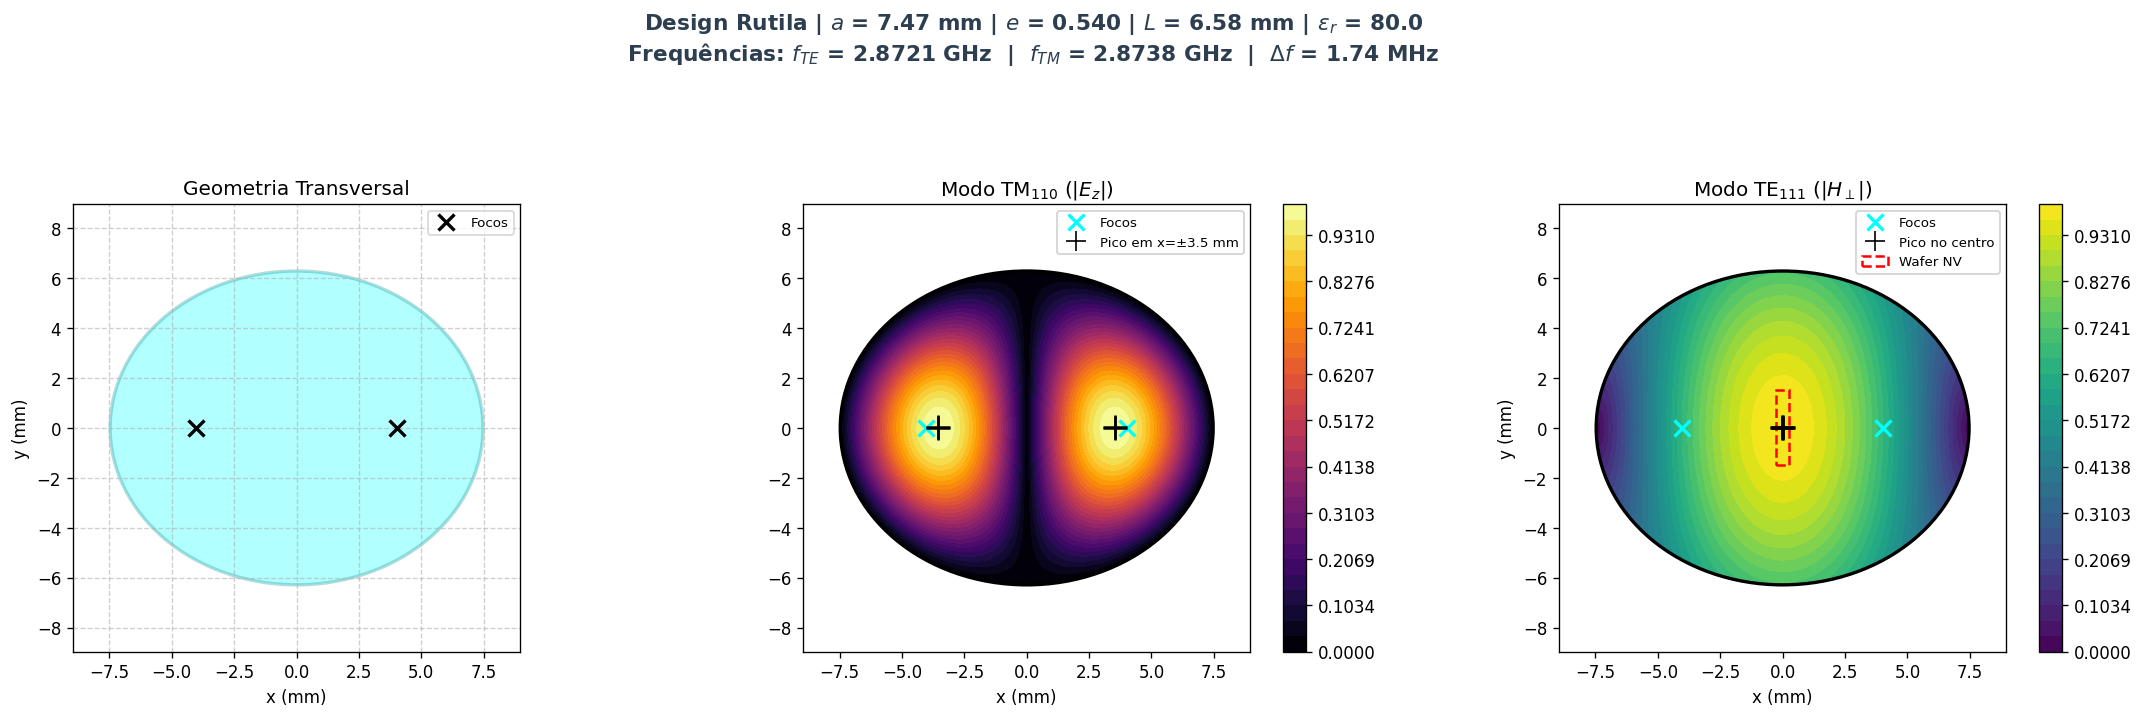

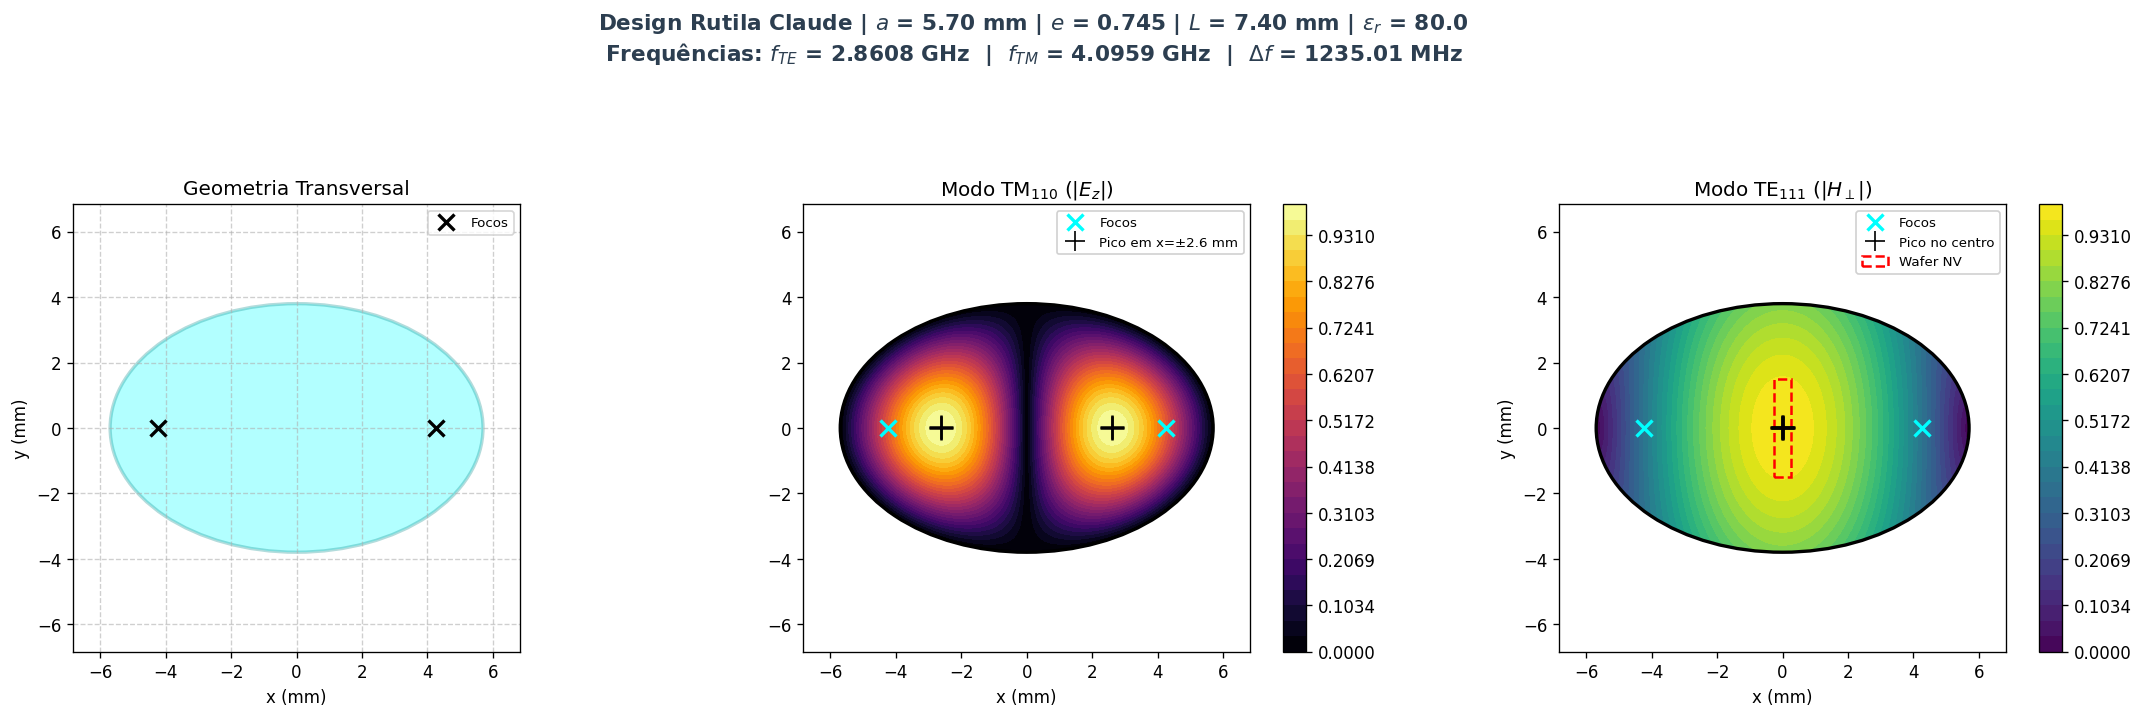

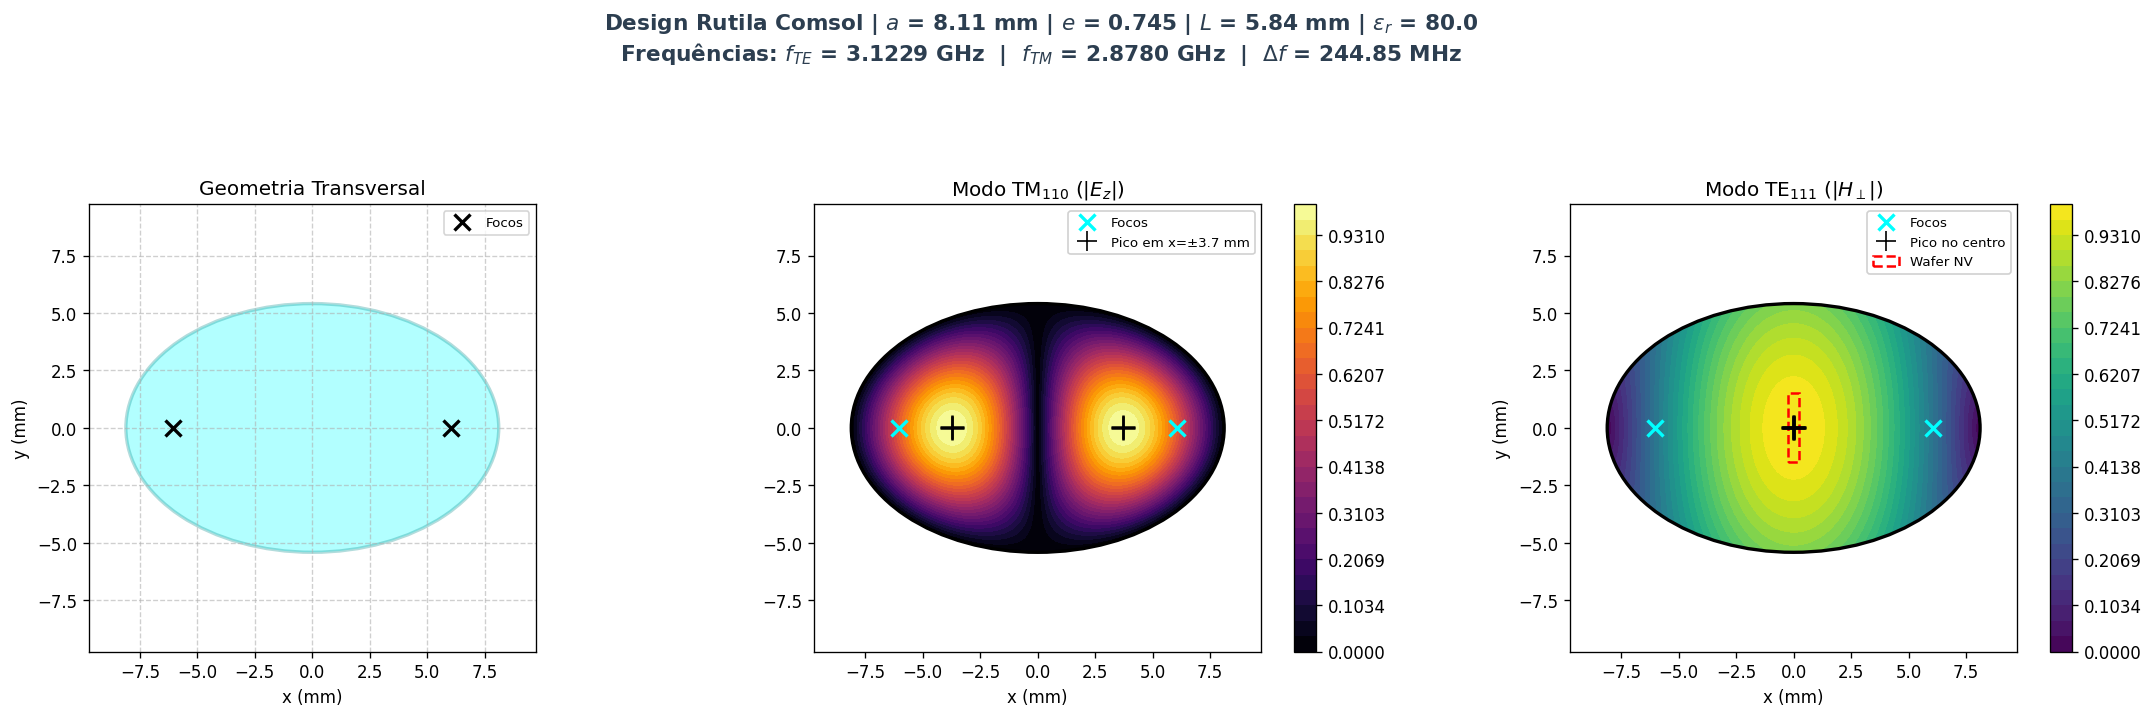

nan


C:\Users\filip\AppData\Local\Temp\ipykernel_10576\215601740.py:30: RuntimeWarning: invalid value encountered in sqrt
  print(np.sqrt(1 - (24./5.70)**2))


In [7]:
# =====================================================================
# EXECUÇÃO DO CASO FIXO (EXEMPLO: RUTILA)
# =====================================================================
if __name__ == '__main__':

    plotar_caso_fixo_1x3(
        a = 7.47, 
        e = 0.54, # np.sqrt(1 - (3.80/5.70)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 6.58, 
        er= 80.0, 
        titulo="Design Rutila"
    )

    plotar_caso_fixo_1x3(
        a = 5.7, 
        e = np.sqrt(1 - (3.80/5.7)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 7.4, 
        er= 80.0, 
        titulo="Design Rutila Claude"
    )

    plotar_caso_fixo_1x3(
        a = 8.11, 
        e = 0.745, # np.sqrt(1 - (34.3/51.4)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 5.84, 
        er= 80.0, 
        titulo="Design Rutila Comsol"
    )

print(np.sqrt(1 - (24./5.70)**2))

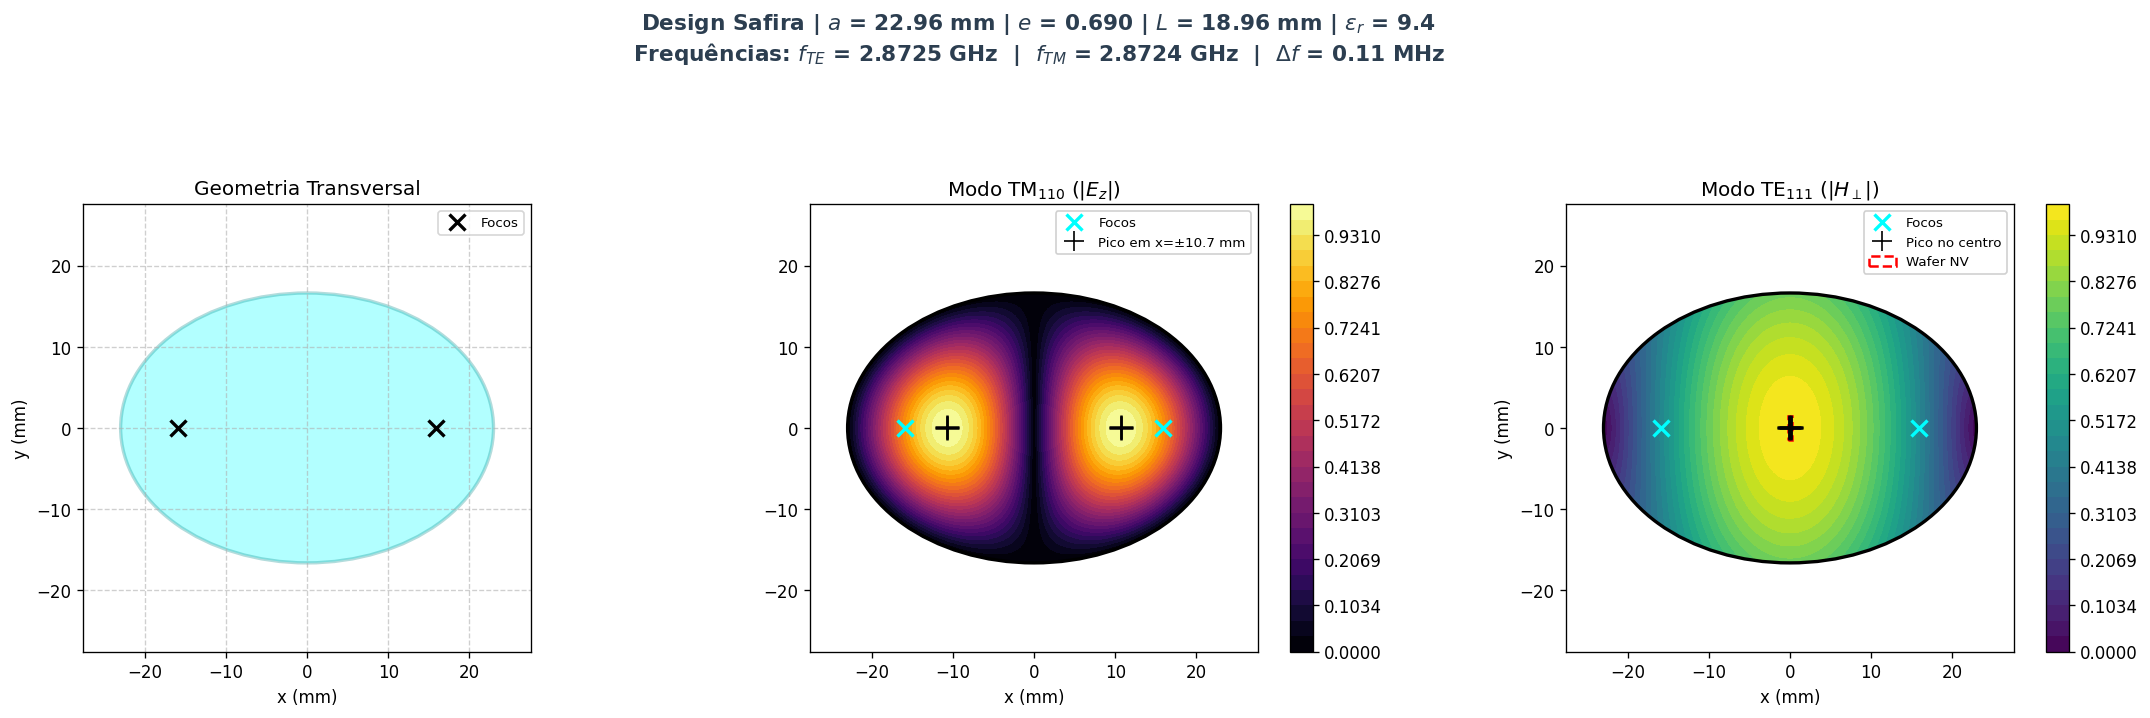

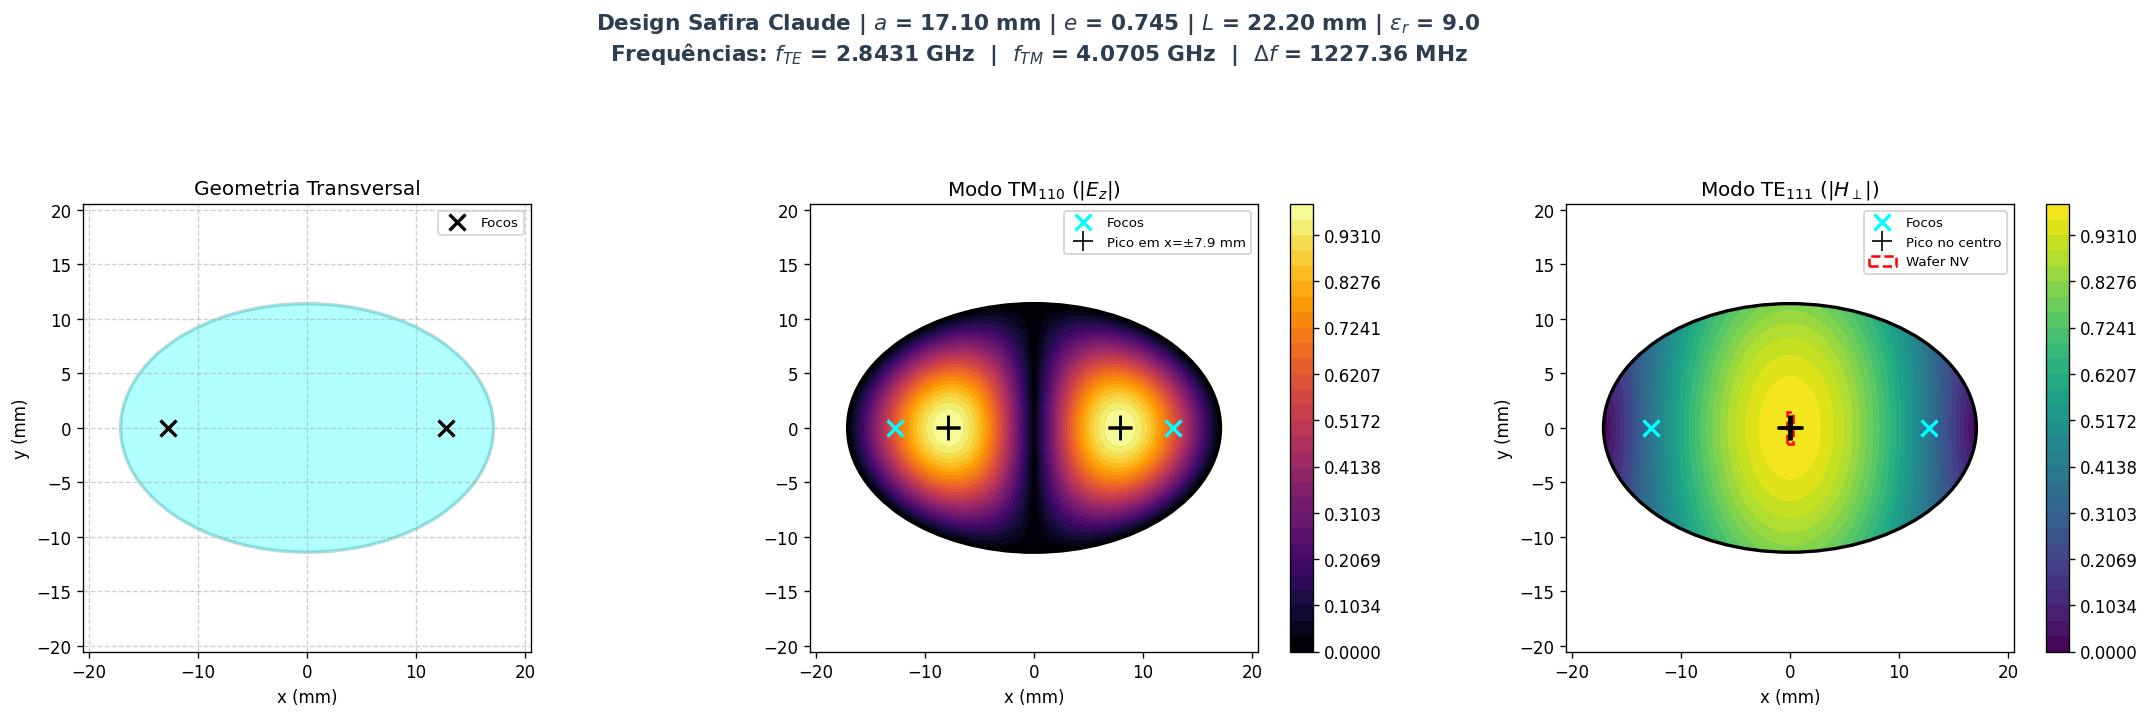

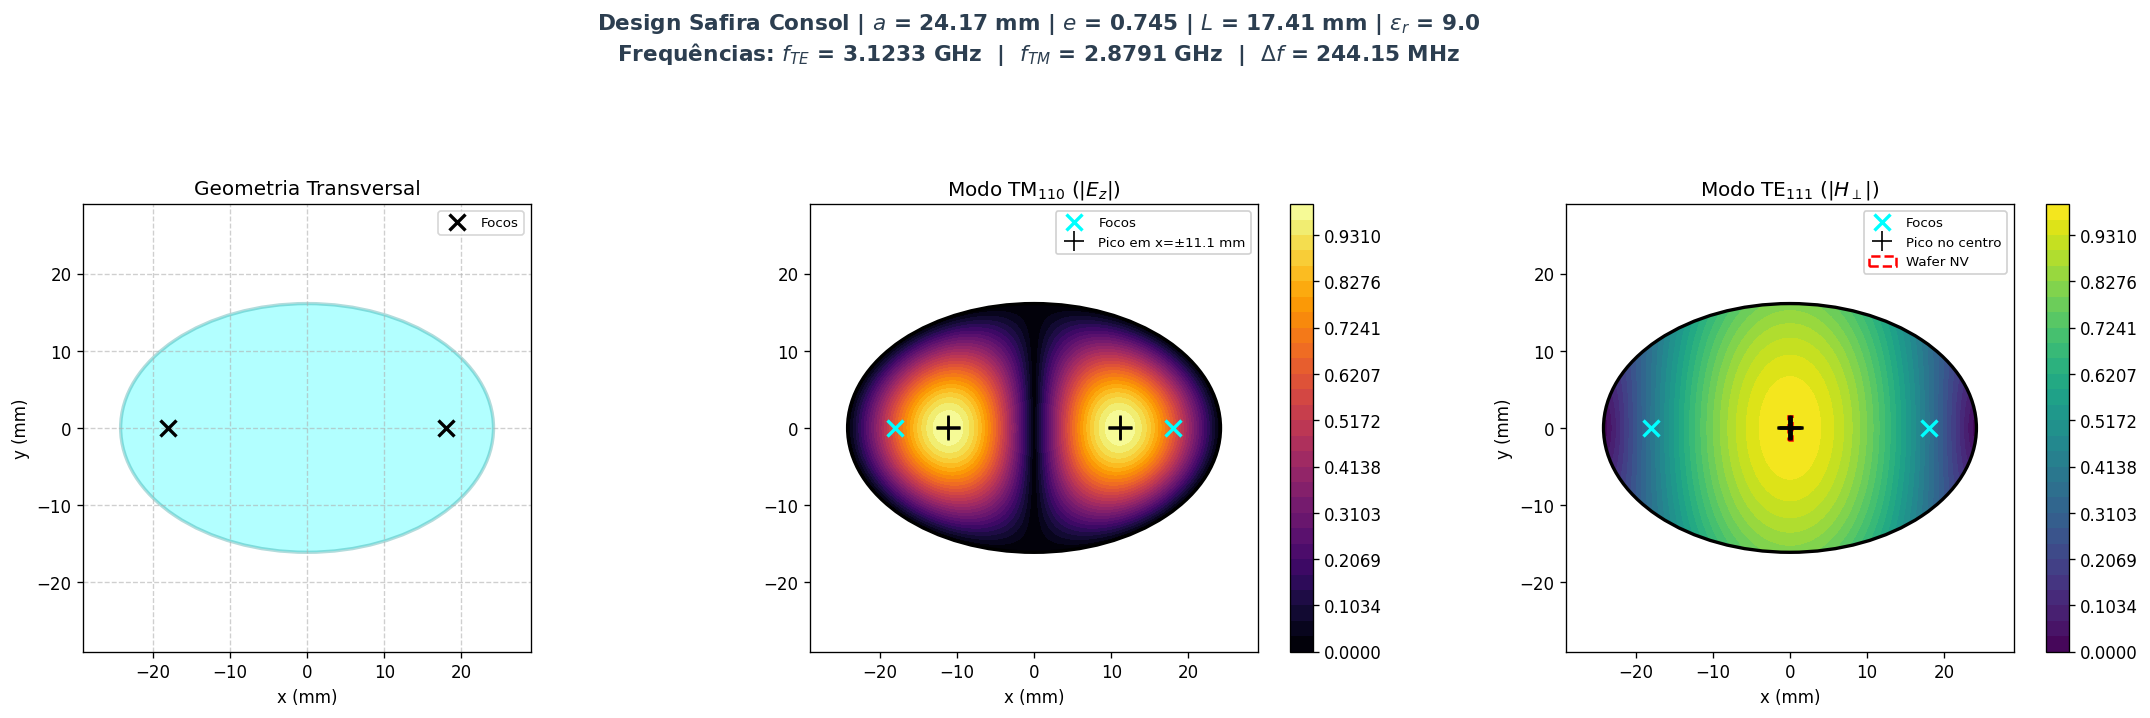

In [8]:
# =====================================================================
# EXECUÇÃO DO CASO FIXO (EXEMPLO: Safira)
# =====================================================================
if __name__ == '__main__':

    plotar_caso_fixo_1x3(
        a = 22.96, 
        e = 0.69, # np.sqrt(1 - (11.4/17.1)**2), # e calculado pelos semi-eixos a=17.1 e b=11.4
        L = 18.96, 
        er= 9.4, 
        titulo="Design Safira"
    )

    plotar_caso_fixo_1x3(
        a = 17.1, 
        e = np.sqrt(1 - (11.4/17.1)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 22.2, 
        er= 9.0, 
        titulo="Design Safira Claude"
    )

    plotar_caso_fixo_1x3(
        a = 24.17, 
        e = 0.745, # np.sqrt(1 - (34.3/51.4)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 17.41, 
        er= 9.0, 
        titulo="Design Safira Consol"
    )

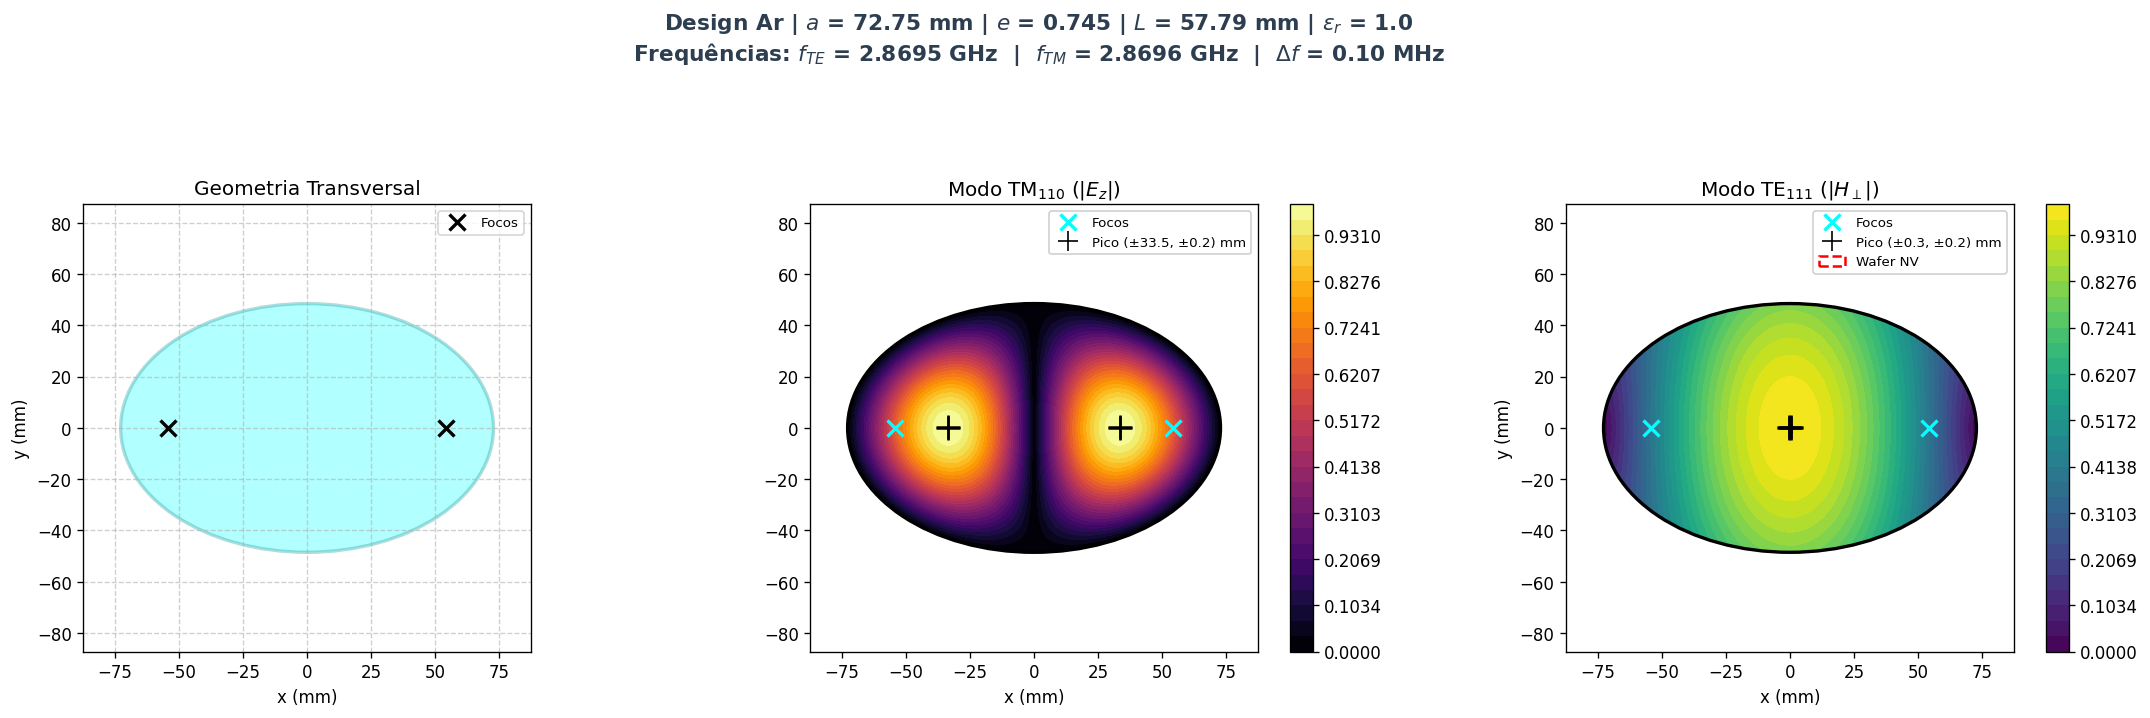

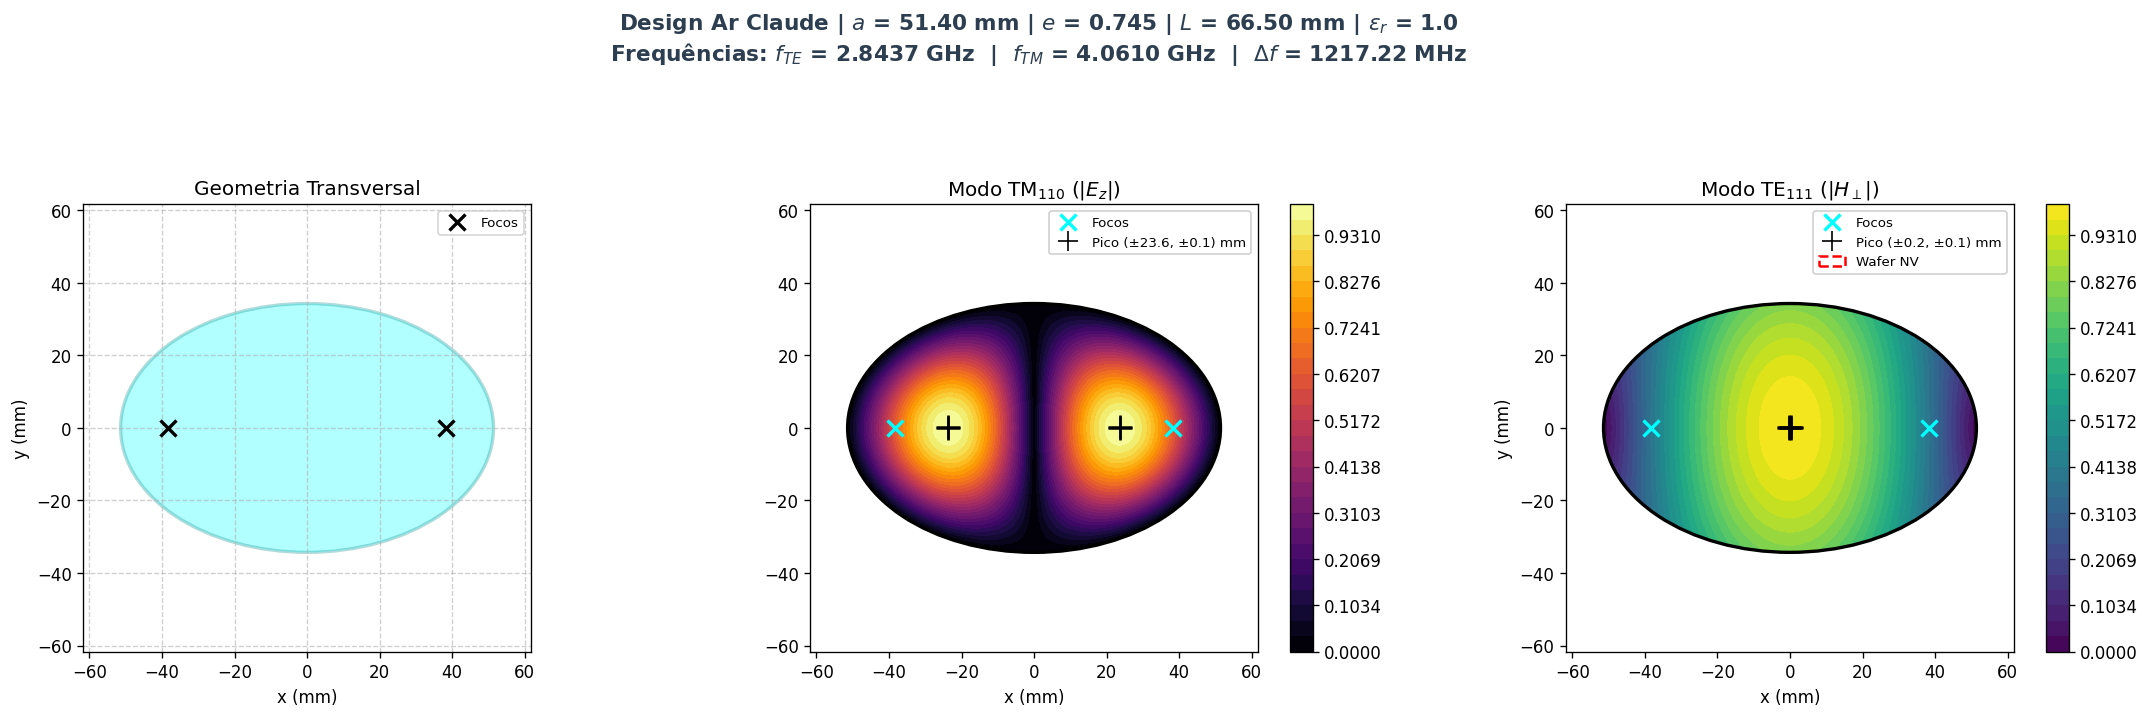

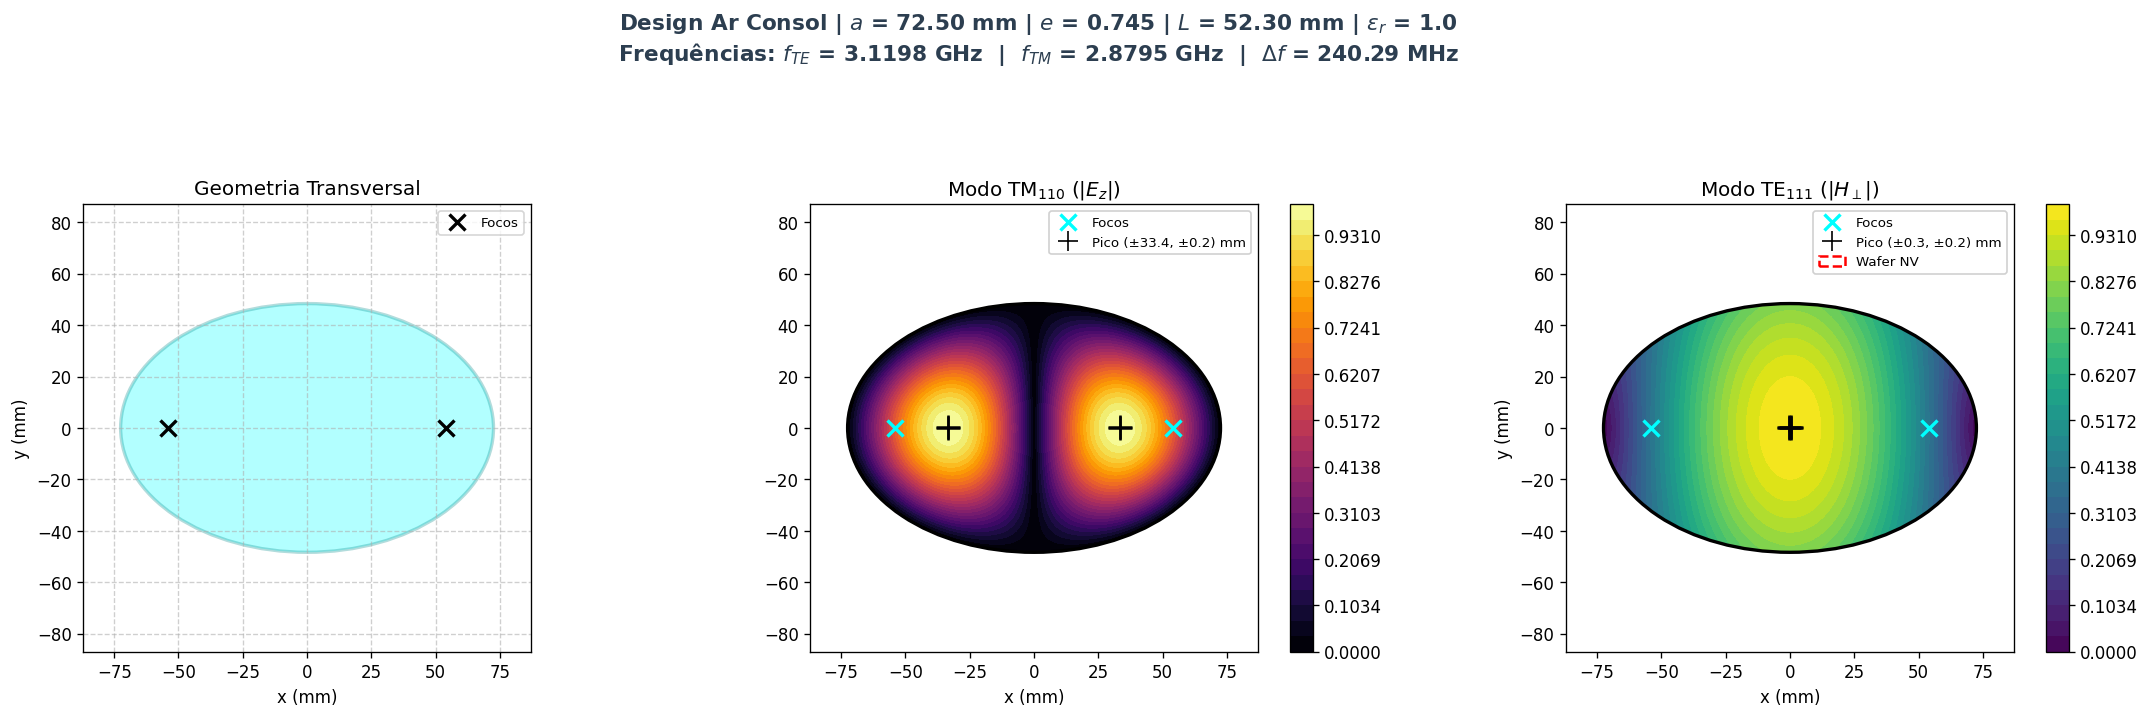

0.9972634360354871


In [9]:
# =====================================================================
# EXECUÇÃO DO CASO FIXO (EXEMPLO: AR)
# =====================================================================
if __name__ == '__main__':

    plotar_caso_fixo_1x3(
        a = 72.75, 
        e = 0.745, # np.sqrt(1 - (3.80/5.70)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 57.79, 
        er= 1.0, 
        titulo="Design Ar"
    )

    plotar_caso_fixo_1x3(
        a = 51.4, 
        e = np.sqrt(1 - (34.3/51.4)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 66.5, 
        er= 1.0, 
        titulo="Design Ar Claude"
    )

    plotar_caso_fixo_1x3(
        a = 72.5, 
        e = 0.745, # np.sqrt(1 - (34.3/51.4)**2), # e calculado pelos semi-eixos a=5.70 e b=3.80
        L = 52.30, 
        er= 1.0, 
        titulo="Design Ar Consol"
    )

print(np.sqrt(1 - (3.80/51.4)**2))